Description:


This Python code performs Exploratory Data Analysis (EDA) using the datasets: sales orders, customers, products, regions, and state regions. It generates summary statistics and visualizations to explore sales trends, regional performance, and other insights, highlighting key patterns and relationships. These findings will later be integrated into Power BI dashboards for interactive and visually appealing business insights.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Base URL for the GitHub repo (RAW format)
base_url = "https://raw.githubusercontent.com/Ilseemerich5/Retail-Sales-Performance-Analysis-with-Python-Power-BI-and-SQL/main/"

# Load datasets


# Customers: load as string first
customers = pd.read_csv(
    base_url + "customers_transformed.csv",
    sep=';',
    dtype=str
)

# Convert purchase dates to datetime
customers['first_purchase_date'] = pd.to_datetime(customers['first_purchase_date'], errors='coerce', dayfirst=True)
customers['last_purchase_date'] = pd.to_datetime(customers['last_purchase_date'], errors='coerce', dayfirst=True)


# Products
products = pd.read_csv(base_url + "products.csv", sep=';', dtype=str)

# Regions
regions = pd.read_csv(base_url + "regions.csv", sep=';', dtype=str)

# State regions
state_regions = pd.read_csv(base_url + "state_regions.csv", sep=';', dtype=str)

# Sales orders
sales_orders = pd.read_csv(
    base_url + "sales_orders_transformed.csv",
    sep=';',
    parse_dates=['order_date'],
    dayfirst=True,
    dtype={
        'order_quantity': 'float64',
        'unit_price': 'float64',
        'line_total': 'float64',
        'total_unit_cost': 'float64',
        'profit': 'float64',
        'profit_margin': 'float64'
    }
)

print(sales_orders.head(10))
print(customers.head(10))
print(products.head(10))
print(regions.head(10))
print(state_regions.head(10))


   order_number order_date  customer_name_index      channel currency_code  \
0  SO - 0002010 2014-01-01                  109  Distributor           USD   
1  SO - 0002504 2014-01-01                   42       Export           USD   
2  SO - 0009931 2014-01-01                   83    Wholesale           USD   
3  SO - 0009346 2014-01-01                  132    Wholesale           USD   
4  SO - 0002468 2014-01-01                   19    Wholesale           USD   
5  SO - 0003850 2014-01-01                  116    Wholesale           USD   
6  SO - 0006279 2014-01-01                   22  Distributor           USD   
7  SO - 0006313 2014-01-01                  129       Export           USD   
8  SO - 0010604 2014-01-01                   95    Wholesale           USD   
9  SO - 0008840 2014-01-01                  156  Distributor           USD   

  warehouse_code  delivery_region_index  product_description_index  \
0         NXH382                    594                         11   
1

In [3]:
# Basic exploration of each table
def summarize_df(df):
    # Quick summary of dataset: shape, first rows, info, and statistics
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    display(df.head(3))
    display(df.info())
    display(df.describe(include='all'))

In [4]:
print("SALES ORDERS")
summarize_df(sales_orders)

SALES ORDERS
Rows: 64104, Columns: 14


,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,line_total,total_unit_cost,profit,profit_margin
0,SO - 0002010,2014-01-01,109,Distributor,USD,NXH382,594,11,11.0,1045.2,11497.2,543.50,501.70,0.48
1,SO - 0002504,2014-01-01,42,Export,USD,FLR025,829,27,11.0,1976.5,21741.5,790.60,1185.90,0.60
2,SO - 0009931,2014-01-01,83,Wholesale,USD,AXW291,19,13,6.0,6525.8,39154.8,3589.19,2936.61,0.45


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_number               64104 non-null  object        
 1   order_date                 64104 non-null  datetime64[ns]
 2   customer_name_index        64104 non-null  int64         
 3   channel                    64104 non-null  object        
 4   currency_code              64104 non-null  object        
 5   warehouse_code             64104 non-null  object        
 6   delivery_region_index      64104 non-null  int64         
 7   product_description_index  64104 non-null  int64         
 8   order_quantity             64104 non-null  float64       
 9   unit_price                 64104 non-null  float64       
 10  line_total                 64104 non-null  float64       
 11  total_unit_cost            64104 non-null  float64       
 12  prof

None

,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,line_total,total_unit_cost,profit,profit_margin
count,64104,64104,64104.000000,64104,64104,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000
unique,10684,NaN,NaN,3,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SO - 0009753,NaN,NaN,Wholesale,USD,AXW291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6,NaN,NaN,34596,64104,30204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2016-01-29 01:28:20.935979264,87.480064,NaN,NaN,NaN,495.086609,14.913141,8.441689,2284.380803,19280.682937,1432.084340,852.296463,0.373594
min,NaN,2014-01-01 00:00:00,1.000000,NaN,NaN,NaN,1.000000,1.000000,5.000000,167.500000,837.500000,68.680000,25.120000,0.150000
25%,NaN,2015-01-13 00:00:00,45.000000,NaN,NaN,NaN,247.000000,6.000000,6.000000,1031.800000,8019.900000,606.220000,335.202500,0.260000
50%,NaN,2016-01-27 00:00:00,87.000000,NaN,NaN,NaN,493.000000,15.000000,8.000000,1855.900000,14023.100000,1084.500000,603.500000,0.370000
75%,NaN,2017-02-13 00:00:00,130.000000,NaN,NaN,NaN,742.000000,24.000000,10.000000,3606.275000,27416.400000,2046.932500,1201.477500,0.490000
max,NaN,2018-02-28 00:00:00,175.000000,NaN,NaN,NaN,994.000000,30.000000,12.000000,6566.000000,78711.600000,5498.560000,3863.220000,0.600000


Results:

The dataset contains 64,104 sales orders across 10,684 unique order numbers and three main sales channels, with Wholesale being the dominant one. The average order includes about 15 units per product at a unit price of 8.44, generating a mean line total of 2,284.38 and an average profit of 852.30 per order. The profit margin averages 37%, ranging from 15% to 60%, indicating generally healthy profitability across the dataset.

In [5]:
print("CUSTOMERS")
summarize_df(customers)

CUSTOMERS
Rows: 175, Columns: 7


,customer_name_index,customer_name,gender,first_purchase_date,last_purchase_date,total_purchases,total_transaction_amount
0,1,Emma Smith,F,2014-01-11,2018-02-12,2754,5516847
1,2,Olivia Johnson,F,2014-01-04,2018-02-28,3072,6832552.8
2,3,Ava Williams,F,2014-01-11,2018-02-27,2676,5595799.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_name_index       175 non-null    object        
 1   customer_name             175 non-null    object        
 2   gender                    175 non-null    object        
 3   first_purchase_date       175 non-null    datetime64[ns]
 4   last_purchase_date        175 non-null    datetime64[ns]
 5   total_purchases           175 non-null    object        
 6   total_transaction_amount  175 non-null    object        
dtypes: datetime64[ns](2), object(5)
memory usage: 9.7+ KB


None

,customer_name_index,customer_name,gender,first_purchase_date,last_purchase_date,total_purchases,total_transaction_amount
count,175,175,175,175,175,175,175
unique,175,175,2,NaN,NaN,133,175
top,1,Emma Smith,F,NaN,NaN,2898,5516847
freq,1,1,152,NaN,NaN,4,1
mean,NaN,NaN,NaN,2014-01-04 07:40:48,2018-02-24 04:39:46.285714176,NaN,NaN
min,NaN,NaN,NaN,2014-01-01 00:00:00,2018-02-10 00:00:00,NaN,NaN
25%,NaN,NaN,NaN,2014-01-02 00:00:00,2018-02-22 00:00:00,NaN,NaN
50%,NaN,NaN,NaN,2014-01-03 00:00:00,2018-02-26 00:00:00,NaN,NaN
75%,NaN,NaN,NaN,2014-01-05 00:00:00,2018-02-28 00:00:00,NaN,NaN
max,NaN,NaN,NaN,2014-02-04 00:00:00,2018-02-28 00:00:00,NaN,NaN


Results:

The dataset includes 175 unique customers, with a clear female majority (152 out of 175). Customers made between 2022 and 4644 purchases, with an average of 3092 purchases per customer. The total transaction amount ranges from 4.03M to 12.64M, averaging around 7.06M. Overall, the data shows a consistent and high purchasing volume per customer, indicating strong customer engagement and loyalty during the analyzed period (2014–2018).

In [6]:
print("PRODUCTS")
summarize_df(products)

PRODUCTS
Rows: 30, Columns: 2


,Index,Product Name
0,1,Montclair Leather Tote
1,2,Riverside Compact Wallet
2,3,Horizon Key Holder


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Index         30 non-null     object
 1   Product Name  30 non-null     object
dtypes: object(2)
memory usage: 612.0+ bytes


None

,Index,Product Name
count,30,30
unique,30,30
top,1,Montclair Leather Tote
freq,1,1


Results:

The dataset includes 30 unique products, each appearing only once. The product index ranges from 1 to 30. The most common product (top by name) is Montclair Leather Tote, but no product is repeated, reflecting a one-to-one mapping between product entries and their index. This dataset serves as a complete reference list of all products for analysis.

In [7]:
print("REGIONS")
summarize_df(regions)

REGIONS
Rows: 994, Columns: 15


,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             994 non-null    object
 1   name           994 non-null    object
 2   county         994 non-null    object
 3   state_code     994 non-null    object
 4   state          994 non-null    object
 5   type           994 non-null    object
 6   latitude       994 non-null    object
 7   longitude      994 non-null    object
 8   area_code      994 non-null    object
 9   population     994 non-null    object
 10  households     994 non-null    object
 11  median_income  994 non-null    object
 12  land_area      994 non-null    object
 13  water_area     994 non-null    object
 14  time_zone      994 non-null    object
dtypes: object(15)
memory usage: 116.6+ KB


None

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
count,994,994,994,994,994,994,994,994,994,994,994,994,994,994,994
unique,994,923,412,48,48,12,990,990,220,972,959,957,970,916,10
top,994,Springfield,Los Angeles County,CA,California,City,42.03336,-71.41617,847,75527,25324,40457,12172451,0,America/New York
freq,1,5,42,186,186,719,2,2,27,2,3,3,2,53,339


Results:

The dataset covers 994 U.S. cities across multiple states and counties. Populations and household counts vary widely, and median incomes average around $59K, providing important context for analyzing regional sales performance, customer reach, and market potential.

In [8]:
print("STATE REGIONS")
summarize_df(state_regions)

STATE REGIONS
Rows: 48, Columns: 3


,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   State Code  48 non-null     object
 1   State       48 non-null     object
 2   Region      48 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


None

,State Code,State,Region
count,48,48,48
unique,48,48,4
top,AL,Alabama,South
freq,1,1,16


Results:

The dataset includes 48 U.S. states, each assigned to one of four regions. This structure allows for regional sales analysis and comparison across geographic areas.

In [9]:
# Double data quality check
# Missing values and duplicates per dataset
for name, df in {
    'Sales Orders': sales_orders,
    'Customers': customers,
    'Products': products,
    'Regions': regions,
    'State Regions': state_regions
}.items():
    print(f"\n{name}")
    print("Missing values:\n", df.isna().sum())
    print("Duplicated rows:", df.duplicated().sum())

  # No missing values were detected


Sales Orders
Missing values:
 order_number                 0
order_date                   0
customer_name_index          0
channel                      0
currency_code                0
warehouse_code               0
delivery_region_index        0
product_description_index    0
order_quantity               0
unit_price                   0
line_total                   0
total_unit_cost              0
profit                       0
profit_margin                0
dtype: int64
Duplicated rows: 0

Customers
Missing values:
 customer_name_index         0
customer_name               0
gender                      0
first_purchase_date         0
last_purchase_date          0
total_purchases             0
total_transaction_amount    0
dtype: int64
Duplicated rows: 0

Products
Missing values:
 Index           0
Product Name    0
dtype: int64
Duplicated rows: 0

Regions
Missing values:
 id               0
name             0
county           0
state_code       0
state            0
type             

In [10]:
# Check total sales (revenue: sum of line_total)
total_revenue = sales_orders['line_total'].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 1235968899.0


In [11]:
# Check total profit (sum of profit * order_quantity)
total_profit = (sales_orders['profit'] * sales_orders['order_quantity']).sum()
print(f"Total Profit: {total_profit}")

Total Profit: 461772324.9


In [12]:
# Average profit margin across all orders
average_profit_margin = sales_orders['profit_margin'].mean()
print(f"Average Profit Margin: {average_profit_margin:.2%}")
# Average profit margin is 37.36%, which indicates strong profitability across orders.


Average Profit Margin: 37.36%


In [13]:
# Total revenue and average profit margin per channel

# Total revenue per channel
revenue_by_channel = sales_orders.groupby('channel')['line_total'].sum()

# Average profit margin per channel
avg_margin_by_channel = sales_orders.groupby('channel').apply(lambda x: (x['profit'] * x['order_quantity']).sum() / x['line_total'].sum())

# Display results
print("Total Revenue per Channel:")
print(revenue_by_channel)
print("Average Profit Margin per Channel:")
print(avg_margin_by_channel.map("{:.2%}".format))


Total Revenue per Channel:
channel
Distributor    387139788.6
Export         180631866.0
Wholesale      668197244.4
Name: line_total, dtype: float64
Average Profit Margin per Channel:
channel
Distributor    37.65%
Export         38.01%
Wholesale      37.02%
dtype: object


/tmp/ipython-input-4192709296.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_margin_by_channel = sales_orders.groupby('channel').apply(lambda x: (x['profit'] * x['order_quantity']).sum() / x['line_total'].sum())


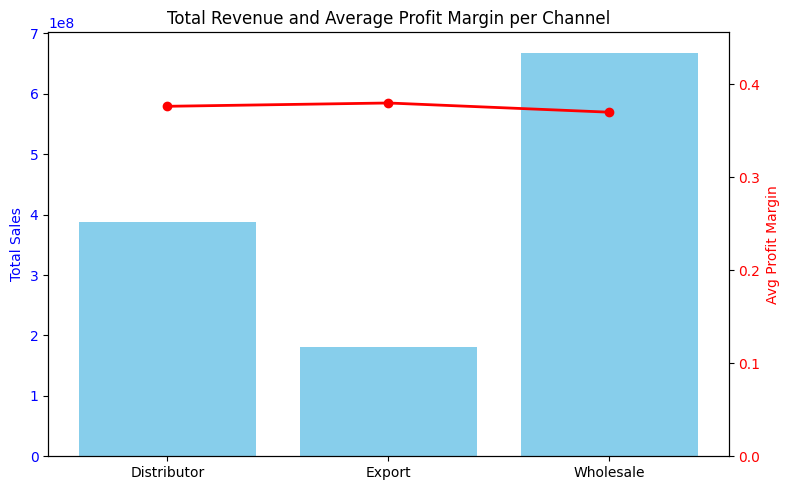

In [14]:
# Total sales (revenue) per channel bar plot
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(revenue_by_channel.index, revenue_by_channel, color='skyblue', label='Total Sales')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Profit margin as line plot on second y-axis
ax2 = ax1.twinx()
ax2.plot(avg_margin_by_channel.index, avg_margin_by_channel, color='red', marker='o', linewidth=2, label='Avg Profit Margin')
ax2.set_ylabel('Avg Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(avg_margin_by_channel)*1.2)  # add some space above max

# Title
plt.title('Total Revenue and Average Profit Margin per Channel')
fig.tight_layout()
plt.show()

Conclusion:

Wholesale generates the highest total revenue, followed by Distributor and Export. Profit margins are relatively similar across channels, with Export slightly higher at 38%, indicating consistent profitability despite differences in sales volume.

In [15]:
# Top 10 States by Sales (revenue)

# Ensure matching data types before merging
sales_orders['delivery_region_index'] = sales_orders['delivery_region_index'].astype(str)
regions['id'] = regions['id'].astype(str)

#  Merge sales_orders with regions to get the state name
sales_regions = sales_orders.merge(regions, left_on='delivery_region_index', right_on='id', how='left')

# Total sales per state
sales_by_state = sales_regions.groupby('state')['line_total'].sum()

# Select top 10 states by sales
top10_states = sales_by_state.sort_values(ascending=False).head(10)

#  Average profit margin per top 10 states
avg_margin_by_state = sales_regions.groupby('state').apply(
    lambda x: (x['profit'] * x['order_quantity']).sum() / x['line_total'].sum()
)
avg_margin_by_state_top10 = avg_margin_by_state.loc[top10_states.index]

# Display results
print("Top 10 States by Total Revenue:")
print(top10_states)

print("Average Profit Margin for Top 10 States:")
print(avg_margin_by_state_top10.map("{:.2%}".format))


Top 10 States by Total Revenue:
state
California       228785436.0
Illinois         111050965.7
Florida           90204679.5
Texas             84011903.0
New York          55534960.0
Indiana           54601690.2
New Jersey        46830956.5
Connecticut       44251228.7
Michigan          39025315.8
Massachusetts     35011942.1
Name: line_total, dtype: float64
Average Profit Margin for Top 10 States:
state
California       37.37%
Illinois         37.39%
Florida          37.27%
Texas            37.43%
New York         37.01%
Indiana          37.44%
New Jersey       36.86%
Connecticut      37.27%
Michigan         37.89%
Massachusetts    37.22%
dtype: object


/tmp/ipython-input-1182899235.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_margin_by_state = sales_regions.groupby('state').apply(


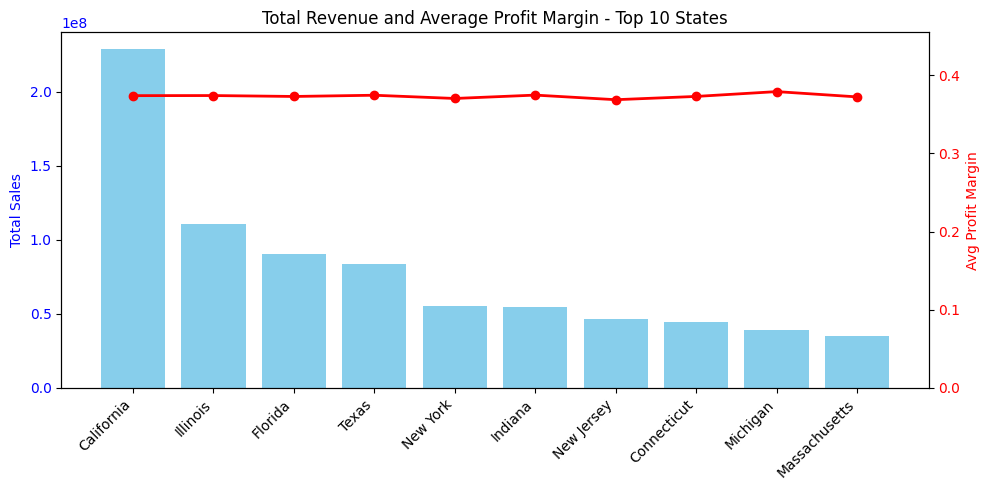

In [16]:
# Top 10 States by Sales (revenue) bar plot

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(top10_states.index, top10_states, color='skyblue', label='Total Sales')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')  # rotate labels

# Line plot for profit margin
ax2 = ax1.twinx()
ax2.plot(avg_margin_by_state_top10.index, avg_margin_by_state_top10, color='red', marker='o', linewidth=2, label='Avg Profit Margin')
ax2.set_ylabel('Avg Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(avg_margin_by_state_top10)*1.2)

plt.title('Total Revenue and Average Profit Margin - Top 10 States')
fig.tight_layout()
plt.show()



Conclusion:

California has the highest revenue, largely due to having the most stores (186). Similarly, Illinois, Florida, and Texas rank high in revenue, corresponding with their relatively higher number of stores. Profit margins across these states remain fairly consistent, around 37–38%, indicating stable profitability despite differences in sales volume and store count.

In [17]:
# Top 10 States by Profit Margin (including store count)

# Calculate average profit margin per state
avg_margin_by_state = sales_regions.groupby('state').apply(
    lambda x: (x['profit'] * x['order_quantity']).sum() / x['line_total'].sum()
)

# Calculate total sales per state (revenue)
sales_by_state = sales_regions.groupby('state')['line_total'].sum()

# Count unique stores (unique region IDs) per state
store_count_by_state = regions.groupby('state')['id'].nunique()

# Select the top 10 states with the highest profit margin
top10_margin_states = avg_margin_by_state.sort_values(ascending=False).head(10)

# Filter matching sales and store data for those states
top10_sales_for_margin_states = sales_by_state.loc[top10_margin_states.index]
top10_store_counts = store_count_by_state.loc[top10_margin_states.index]

# Results
print("Top 10 States by Profit Margin")
top10_summary = pd.DataFrame({
    'Total Revenue': top10_sales_for_margin_states,
    'Average Profit Margin': top10_margin_states.map("{:.2%}".format),
    'Store Count': top10_store_counts
})
print(top10_summary)


Top 10 States by Profit Margin
          Total Revenue Average Profit Margin  Store Count
state                                                     
Nebraska      4936298.7                39.36%            4
Wyoming       1769825.1                38.91%            2
Montana       3415070.4                38.78%            3
Virginia     21385026.5                38.08%           17
Michigan     39025315.8                37.89%           32
Utah         17914393.0                37.85%           14
Oregon       16100106.7                37.85%           13
Georgia      20726912.3                37.78%           16
Arizona      23388246.1                37.73%           20
Ohio         25214518.7                37.69%           22


/tmp/ipython-input-3520418525.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_margin_by_state = sales_regions.groupby('state').apply(


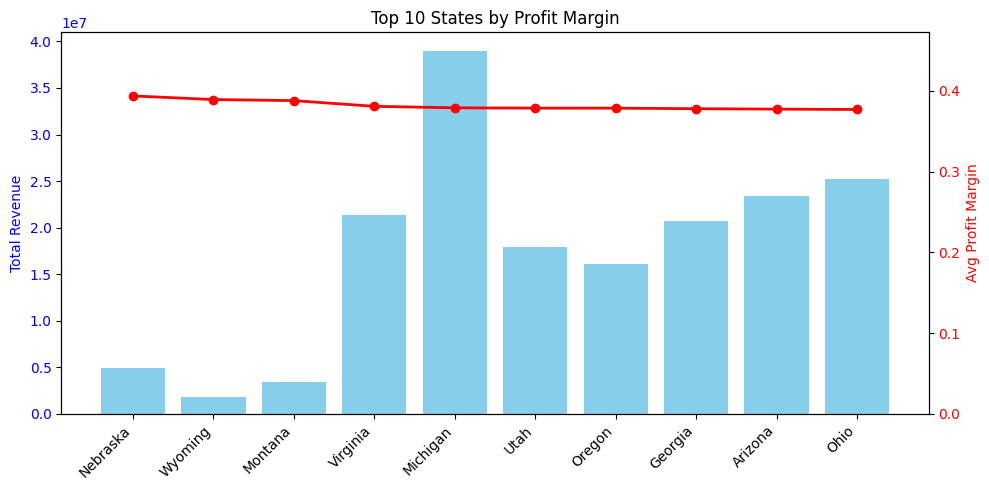

In [18]:
# Visualization
fig, ax1 = plt.subplots(figsize=(10,5))

# Bar plot for total salrevenuees (left axis)
ax1.bar(
    top10_sales_for_margin_states.index,
    top10_sales_for_margin_states,
    color='skyblue',
    label='Total Sales'
)
ax1.set_ylabel('Total Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')  # rotate labels for better readability

# Line plot for profit margin (right axis)
ax2 = ax1.twinx()
ax2.plot(
    top10_margin_states.index,
    top10_margin_states,
    color='red',
    marker='o',
    linewidth=2,
    label='Avg Profit Margin'
)
ax2.set_ylabel('Avg Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, max(top10_margin_states) * 1.2)

plt.title('Top 10 States by Profit Margin')
fig.tight_layout()
plt.show()


Conclusion:

States like Nebraska, Wyoming, and Montana have the highest profit margins (38–39%) despite having few stores, showing strong efficiency per location. Larger states such as Michigan, Arizona, and Ohio maintain slightly lower but still healthy margins (37–38%) while supporting higher total revenue due to more stores. This highlights that profitability per store can differ from total revenue, emphasizing the importance of both efficiency and scale.

In [19]:
# Top 10 Products sold by Profit Margin

# Ensure matching data types before merging
sales_orders['product_description_index'] = sales_orders['product_description_index'].astype(str)
products['Index'] = products['Index'].astype(str)

# Aggregate by product_description_index
product_summary = sales_orders.groupby('product_description_index').agg(
    Average_Profit_Margin=('profit_margin', 'mean'),
    Total_Number_of_Sales=('order_quantity', 'sum'),
    Total_Revenue=('line_total', 'sum')
)

# Sort by Average Profit Margin descending and get top 10
top10_products = product_summary.sort_values(by='Average_Profit_Margin', ascending=False).head(10)

# Merge only top 10 indices with product names
top10_products_with_names = top10_products.reset_index().merge(
    products[['Index', 'Product Name']],
    left_on='product_description_index',
    right_on='Index',
    how='left'
)

# Delete the extra column created during the merge
top10_products_with_names = top10_products_with_names.drop(columns=['Index'])

# Reorder columns
top10_products_with_names = top10_products_with_names[
    ['Product Name', 'Average_Profit_Margin', 'Total_Number_of_Sales', 'Total_Revenue']
]

# Display the results
print("Top 10 Products by Average Profit Margin")
print(top10_products_with_names)


Top 10 Products by Average Profit Margin
                Product Name  Average_Profit_Margin  Total_Number_of_Sales  \
0     Aspen Leather Backpack               0.398963                 6846.0   
1            Atlas Weekender               0.393889                 8286.0   
2  Lumen Limited Edition Bag               0.385500                 8010.0   
3        Eterna Limited Tote               0.384518                15210.0   
4    Pioneer Passport Holder               0.381520                 8832.0   
5     Montclair Leather Tote               0.381343                24138.0   
6            Mint Coin Purse               0.381205                 8574.0   
7       Sienna Crossbody Bag               0.380090                28692.0   
8   Everly Leather Briefcase               0.378319                17682.0   
9         Beacon Card Holder               0.377913                16578.0   

   Total_Revenue  
0     14598630.0  
1     17058267.0  
2     15311014.2  
3     34446174.0  
4    

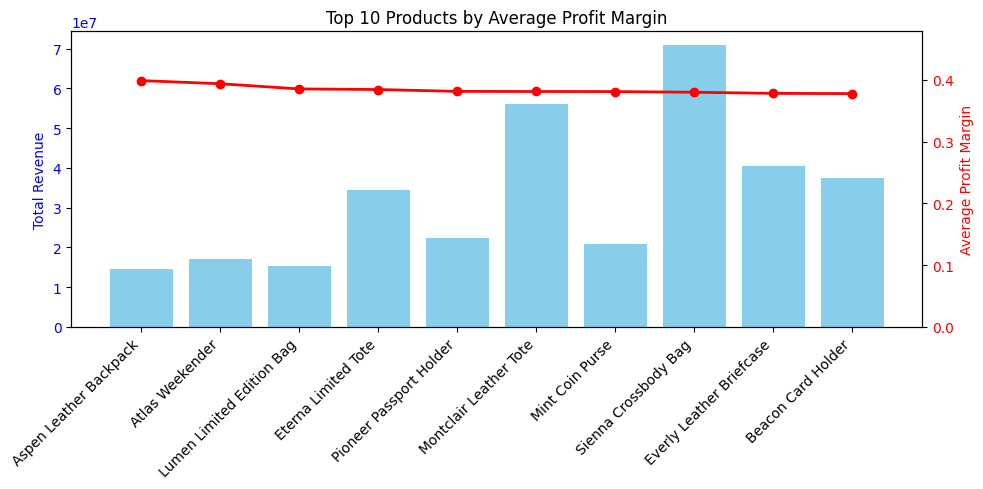

In [20]:
# Visualization

fig, ax1 = plt.subplots(figsize=(10,5))

# Bar plot: total revenue
ax1.bar(
    top10_products_with_names['Product Name'],
    top10_products_with_names['Total_Revenue'],
    color='skyblue',
    label='Total Revenue'
)
ax1.set_ylabel('Total Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# Line plot: average profit margin
ax2 = ax1.twinx()
ax2.plot(
    top10_products_with_names['Product Name'],
    top10_products_with_names['Average_Profit_Margin'],
    color='red',
    marker='o',
    linewidth=2,
    label='Average Profit Margin'
)
ax2.set_ylabel('Average Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, top10_products_with_names['Average_Profit_Margin'].max() * 1.2)

plt.title('Top 10 Products by Average Profit Margin')
fig.tight_layout()
plt.show()


Conclusion:

The top 10 products by average profit margin show consistently high profitability, with margins around 38–40%. The Aspen Leather Backpack leads with the highest margin (39.9%), while products like the Sienna Crossbody Bag and Montclair Leather Tote combine strong margins with the highest total revenues, indicating both profitability and high sales performance.

In [21]:
# Top 10 Products sold by Total Revenue

# Aggregate by product_description_index
product_summary = sales_orders.groupby('product_description_index').agg(
    Average_Profit_Margin=('profit_margin', 'mean'),  # average profit margin
    Total_Number_of_Sales=('order_quantity', 'sum'),  # sum of quantities sold
    Total_Revenue=('line_total', 'sum')               # sum of revenue
)

# Sort by Total Revenue descending and get top 10
top10_products = product_summary.sort_values(by='Total_Revenue', ascending=False).head(10)

# Merge only top 10 indices with products to get Product Name
top10_products_with_names = top10_products.reset_index().merge(
    products[['Index', 'Product Name']],   # using 'Index' and 'Product Name'
    left_on='product_description_index',  # from top10_products
    right_on='Index',                      # column 'Index' from products
    how='left'
)

# Delete the extra column ‘Index’ that was created during the merge
top10_products_with_names = top10_products_with_names.drop(columns=['Index'])

# Reorder columns
top10_products_with_names = top10_products_with_names[
    ['Product Name', 'Average_Profit_Margin', 'Total_Number_of_Sales', 'Total_Revenue']
]

print("Top 10 Products by Total Revenue")
print(top10_products_with_names)


Top 10 Products by Total Revenue
               Product Name  Average_Profit_Margin  Total_Number_of_Sales  \
0            Edge Card Case               0.376063                50364.0   
1           Canyon Belt Bag               0.374164                50358.0   
2        Harbor Satchel Bag               0.371945                34014.0   
3         Saddle Bucket Bag               0.362379                32484.0   
4      Sienna Crossbody Bag               0.380090                28692.0   
5        Aurora Evening Bag               0.366023                31242.0   
6  Riverside Compact Wallet               0.358786                26304.0   
7       Summit Travel Pouch               0.370208                24072.0   
8    Montclair Leather Tote               0.381343                24138.0   
9        Horizon Key Holder               0.370385                23748.0   

   Total_Revenue  
0    117291821.4  
1    109473966.6  
2     78281379.6  
3     75390396.6  
4     70804380.6  
5    

/tmp/ipython-input-3546180679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


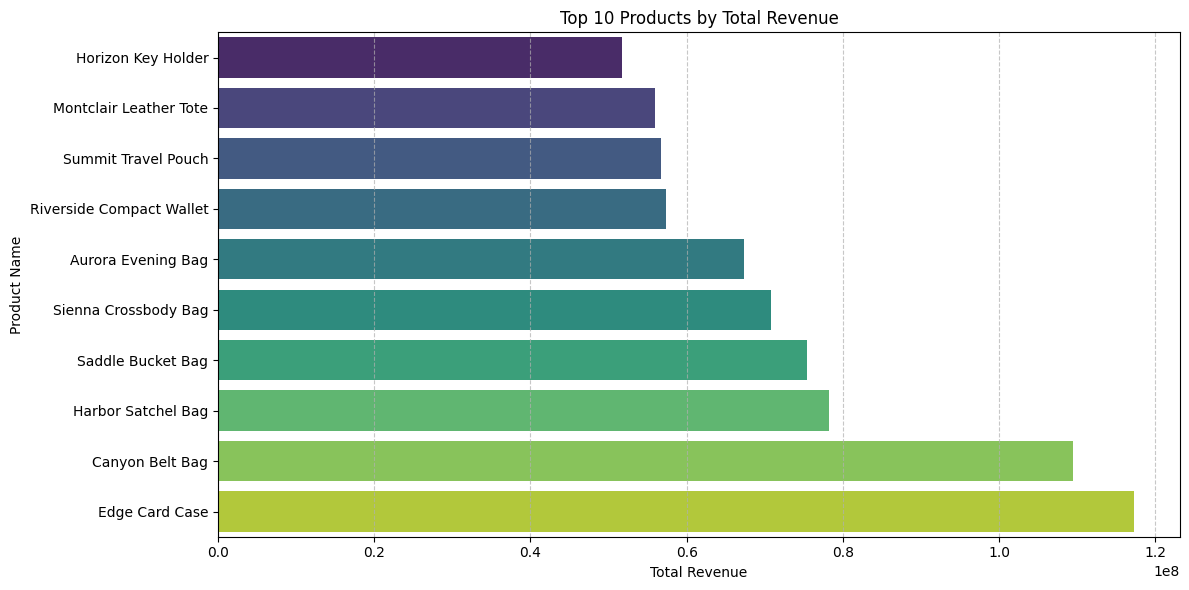

In [22]:
# Visualization

# Sort products from lowest to highest Total Revenue for better visualization
top10_products_with_names_sorted = top10_products_with_names.sort_values(by='Total_Revenue', ascending=True)

# Create the bar plot
plt.figure(figsize=(12,6))
sns.barplot(
    x='Total_Revenue',
    y='Product Name',
    data=top10_products_with_names_sorted,
    palette='viridis'
)

plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Total Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Conclusion:

Based on the analysis of the top 10 products by total revenue, we can conclude that certain products generate significantly higher sales despite having relatively similar profit margins. The Edge Card Case and Canyon Belt Bag lead in total revenue, driven by both high sales quantities and strong margins. Overall, the data shows that high revenue is not solely determined by the highest profit margin; products that balance good pricing, strong demand, and reasonable margins contribute most to total revenue. This highlights the importance of considering both sales volume and profitability when evaluating product performance.

In [23]:
# Last year trend summary

# Ensure order_date is datetime
sales_orders['order_date'] = pd.to_datetime(sales_orders['order_date'])

# Create Year-Month column
sales_orders['Year_Month'] = sales_orders['order_date'].dt.to_period('M')

# Define the period for the last 12 months (March 2017 to February 2018)
start_period = pd.Period('2017-03', freq='M')
end_period = pd.Period('2018-02', freq='M')

# Create a complete period range for the last year
all_months = pd.period_range(start_period, end_period, freq='M')

# Filter and aggregate monthly for the last year
monthly_summary = sales_orders.groupby('Year_Month').agg(
    Total_Revenue=('line_total', 'sum'),
    Total_Quantity=('order_quantity', 'sum'),
    Average_Profit_Margin=('profit_margin', 'mean')
).reindex(all_months, fill_value=0).reset_index()

# Print the monthly summary
print("Monthly Summary for the Last Year (Mar 2017 - Feb 2018)")
print(monthly_summary)


Monthly Summary for the Last Year (Mar 2017 - Feb 2018)
      index  Total_Revenue  Total_Quantity  Average_Profit_Margin
0   2017-03     26123159.3         11416.0               0.374212
1   2017-04     23447990.0         10300.0               0.370410
2   2017-05     26348721.5         11383.0               0.373093
3   2017-06     23761335.6         10333.0               0.372541
4   2017-07     24070011.3         10853.0               0.369025
5   2017-08     25301062.6         10731.0               0.375051
6   2017-09     24758657.4         10846.0               0.378059
7   2017-10     25366709.2         10993.0               0.378259
8   2017-11     24364844.8         10924.0               0.369969
9   2017-12     25022557.0         10954.0               0.373823
10  2018-01     24685185.2         10917.0               0.368973
11  2018-02     23444767.3         10162.0               0.371817


/tmp/ipython-input-2293832363.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_summary = last_year_data.groupby(pd.Grouper(key='order_date', freq='M')).agg(


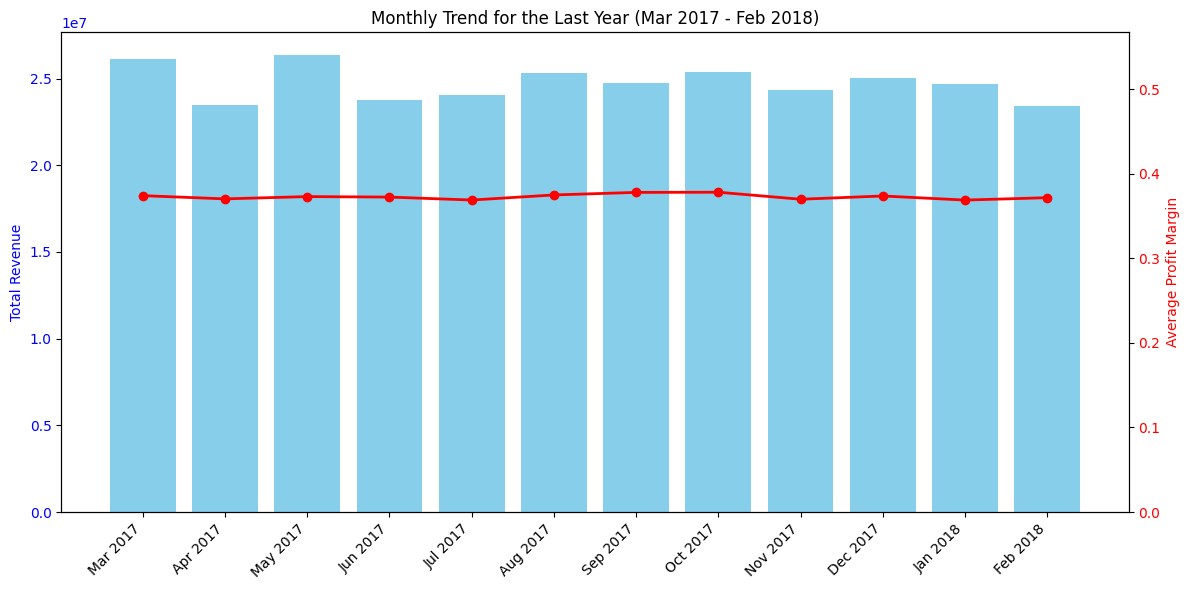

In [24]:
# Visualization

# Filter only the last year: Mar 2017 - Feb 2018
mask = (sales_orders['order_date'] >= '2017-03-01') & (sales_orders['order_date'] <= '2018-02-28')
last_year_data = sales_orders.loc[mask]

# Group by month using pd.Grouper
monthly_summary = last_year_data.groupby(pd.Grouper(key='order_date', freq='M')).agg(
    Total_Revenue=('line_total', 'sum'),
    Total_Quantity=('order_quantity', 'sum'),
    Average_Profit_Margin=('profit_margin', 'mean')
).reset_index()

# Convert date to string for plotting
monthly_summary['Month_Str'] = monthly_summary['order_date'].dt.strftime('%b %Y')

# Simple plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot: Total Revenue
ax1.bar(monthly_summary['Month_Str'], monthly_summary['Total_Revenue'], color='skyblue')
ax1.set_ylabel('Total Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# Line plot: Average Profit Margin
ax2 = ax1.twinx()
ax2.plot(monthly_summary['Month_Str'], monthly_summary['Average_Profit_Margin'], color='red', marker='o', linewidth=2)
ax2.set_ylabel('Average Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, monthly_summary['Average_Profit_Margin'].max() * 1.5)

plt.title('Monthly Trend for the Last Year (Mar 2017 - Feb 2018)')
plt.tight_layout()
plt.show()


Conclusion:

The total revenue in the last year was relatively stable from March 2017 to February 2018, showing consistent performance across the year. The highest revenue was recorded in May 2017, while the lowest occurred in February 2018. Despite small month-to-month fluctuations, the average profit margin stayed steady around 37%, indicating healthy profitability and cost management. Overall, the company maintained a balanced trend in both sales and profitability throughout the 12-month period, with no major downturns or spikes suggesting volatility.

In [25]:
# Monthly Revenue pivot table to analyze Seasonality

# Extract Year and Month
sales_orders['Year'] = sales_orders['order_date'].dt.year
sales_orders['Month'] = sales_orders['order_date'].dt.month

# Group by Year and Month to calculate total revenue
monthly_sales = sales_orders.groupby(['Year', 'Month'], as_index=False).agg({
    'line_total': 'sum'
})

# Rename column for clarity
monthly_sales.rename(columns={'line_total': 'Total_Revenue'}, inplace=True)

# Create a pivot table: months as rows, years as columns
pivot_revenue = monthly_sales.pivot_table(
    index='Month',
    columns='Year',
    values='Total_Revenue',
    aggfunc='sum'
)

# Drop months where all years have NaN (no data)
pivot_revenue = pivot_revenue.dropna(how='all')

# Sort months in ascending order
pivot_revenue = pivot_revenue.sort_index()

# Display the pivot table
print("Pivot Table - Total Revenue by Month and Year")
print(pivot_revenue)

Pivot Table - Total Revenue by Month and Year
Year         2014        2015        2016        2017        2018
Month                                                            
1      25020272.3  25525914.6  24862829.0  24017201.9  24685185.2
2      23882719.5  23027431.0  23151247.0  21241586.2  23444767.3
3      23709035.4  24360945.4  26420512.0  26123159.3         NaN
4      24853382.0  23744217.1  23179165.9  23447990.0         NaN
5      25662165.8  24995904.4  25265324.8  26348721.5         NaN
6      23818794.8  24528391.8  24804170.5  23761335.6         NaN
7      23491988.9  24808203.9  24814997.7  24070011.3         NaN
8      25408229.1  26155634.2  25082099.9  25301062.6         NaN
9      25459497.5  24662586.1  24551560.4  24758657.4         NaN
10     24259835.7  25466197.5  25896129.8  25366709.2         NaN
11     26268221.0  25573136.2  25078997.8  24364844.8         NaN
12     25686587.3  25562148.2  24976635.2  25022557.0         NaN


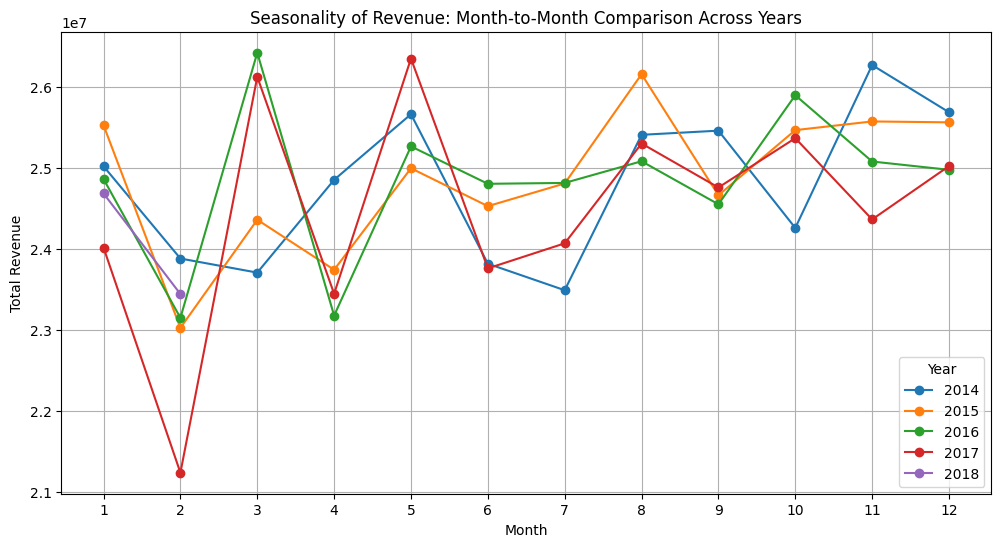

In [26]:
# Visualize seasonality
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot revenue seasonality
for year in pivot_revenue.columns:
    plt.plot(pivot_revenue.index, pivot_revenue[year], marker='o', label=str(year))

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Seasonality of Revenue: Month-to-Month Comparison Across Years')
plt.legend(title='Year')
plt.grid(True)
plt.show()


Conclusion:

The seasonality analysis reveals a generally consistent revenue trend across the years, with notable peaks in March, May, and from October to December. These periods likely reflect strategic sales cycles, seasonal demand, or promotional activities driving higher performance. In contrast, February and April tend to show lower revenue levels. Overall, the company demonstrates strong and predictable revenue stability, supported by effective planning and sustained customer demand throughout the year.

The increase in total revenue observed in March, May, and from October to December can be attributed to seasonal and strategic business factors. March and May often reflect the impact of spring promotions, restocking activities, or quarterly performance boosts, as companies aim to strengthen early-year sales. Toward the end of the year, the rise in revenue from October to December is commonly driven by holiday-related demand, year-end sales campaigns, and corporate budget utilization. These patterns suggest that the company’s sales performance is influenced not only by consumer seasonality but also by strategic timing in marketing and fiscal cycles.

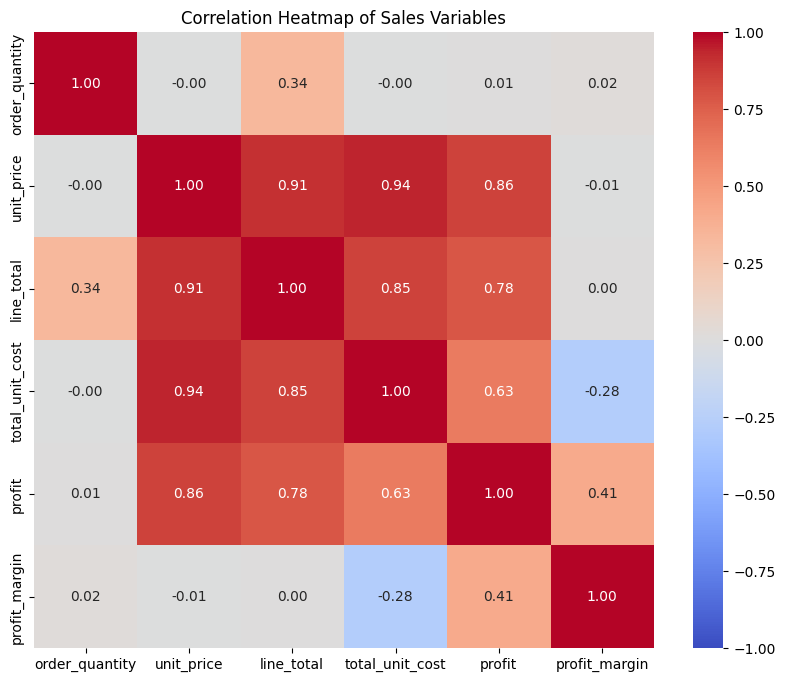

In [27]:
# Correlation

# Select numeric columns relevant for correlation
numeric_cols = [
    'order_quantity', # number of units sold
    'unit_price', # price per unit
    'line_total', # total revenue per line
    'total_unit_cost', # total cost per line
    'profit', # profit per line
    'profit_margin'# profit margin per line
]

# Calculate correlation matrix
correlation_matrix = sales_orders[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True, # show correlation values
    cmap='coolwarm', # color map from blue to red
    fmt=".2f", # format numbers to 2 decimals
    vmin=-1, vmax=1 # fixed color scale for easier interpretation
)

plt.title('Correlation Heatmap of Sales Variables')
plt.show()


Conclusion:


Based on the Correlation Heatmap of Sales Variables, the data reveals strong relationships between financial performance metrics, which is crucial for business analysis. The variables unit_price, line_total, and total_unit_cost are highly and positively correlated with each other (all correlations are above 0.86), indicating that as the price of a unit and its cost increase, the overall line total (revenue) strongly increases as well. Profit is also highly correlated with these three variables (correlations of 0.86 with unit_price, 0.78 with line_total, and 0.64 with total_unit_cost), confirming that profit is primarily driven by the scale and value (price/cost) of transactions. This implies that the business should prioritize strategies focused on high-value products rather than solely on high-volume transactions to maximize overall profitability.

In [28]:
# Analyzing price sensitivity by checking if higher-priced products sell less but have higher profit margins
# Aggregate by product
product_summary = sales_orders.groupby('product_description_index').agg(
    Avg_Unit_Price=('unit_price', 'mean'),
    Total_Quantity=('order_quantity', 'sum'),
    Avg_Profit_Margin=('profit_margin', 'mean')
).reset_index()

print(product_summary.head())


  product_description_index  Avg_Unit_Price  Total_Quantity  Avg_Profit_Margin
0                         1     2297.297107         24138.0           0.381343
1                        10     2371.938621          7398.0           0.371793
2                        11     2584.828655          8832.0           0.381520
3                        12     2596.012022          9396.0           0.369016
4                        13     2300.686322         34014.0           0.371945


Conclusion:

The analysis suggests that products with higher average unit prices tend to have slightly lower sales volumes, but they maintain stable or even higher profit margins. This indicates a moderate price sensitivity among customers, while higher prices may reduce total quantity sold, the profitability per unit remains strong, helping sustain overall revenue. Therefore, the company could focus on balancing premium pricing with volume strategies, optimizing margins without significantly compromising demand.

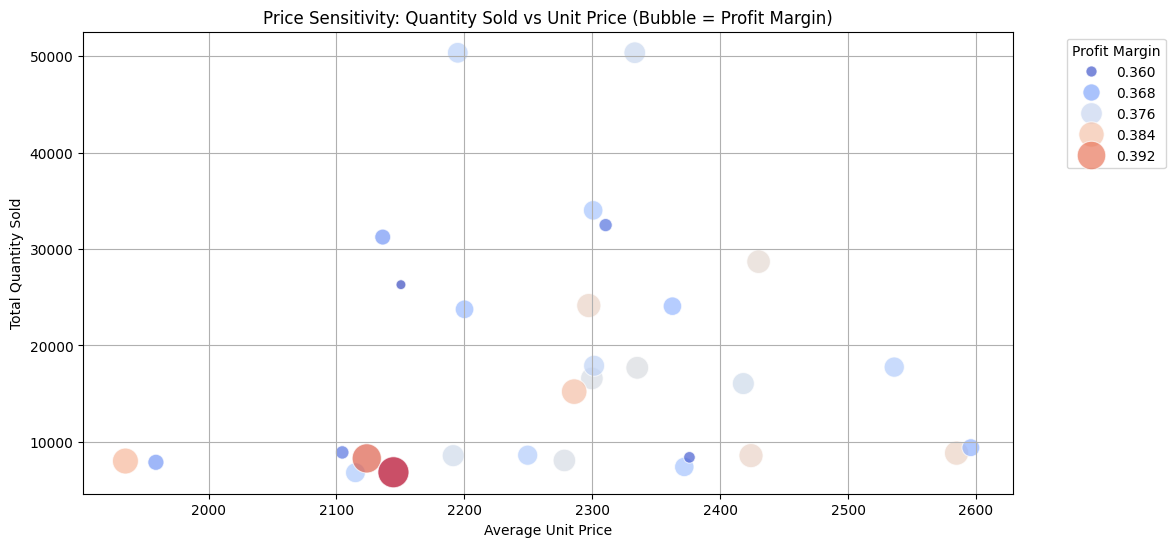

In [29]:
# Scatter plot: Quantity sold vs Unit Price, bubble size = Profit Margin

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=product_summary,
    x='Avg_Unit_Price', # X-axis: average price
    y='Total_Quantity', # Y-axis: total quantity sold
    size='Avg_Profit_Margin', # Bubble size proportional to profit margin
    hue='Avg_Profit_Margin', # Color by profit margin
    palette='coolwarm',
    alpha=0.7,
    sizes=(50, 500) # Adjust bubble size range
)

plt.xlabel('Average Unit Price')
plt.ylabel('Total Quantity Sold')
plt.title('Price Sensitivity: Quantity Sold vs Unit Price (Bubble = Profit Margin)')
plt.grid(True)
plt.legend(title='Profit Margin', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Conclusion:

This chart shows that there is no strong correlation between product price, sales volume, and profit margin. It highlights that the lowest-priced products are not necessarily the best-sellers or the most profitable. In fact, the products with the highest sales and profit margins generally fall within the mid-price range, suggesting that optimal pricing balances both demand and profitability.

In [30]:
# Product-Level revenue, cost, and profit analysis to spot products that might be unprofitable or inefficient

# Aggregate by product
product_cost_revenue = sales_orders.groupby('product_description_index').agg(
    Total_Revenue=('line_total', 'sum'),
    Total_Cost=('total_unit_cost', 'sum'),
    Total_Profit=('profit', 'sum')
).reset_index()

print(product_cost_revenue.head())


  product_description_index  Total_Revenue  Total_Cost  Total_Profit
0                         1     55952289.6  4084681.92    2586668.88
1                        10     17660583.6  1304306.22     759280.38
2                        11     22324426.8  1683896.16     968138.04
3                        12     24173184.6  1864128.36     986292.84
4                        13     78281379.6  5727375.42    3355734.18


Reuslts:

The data shows that while some products generate very high revenue, their associated costs are also significant, yet the resulting profits remain relatively modest compared to revenue. This highlights that high-revenue products are not necessarily the most cost-efficient, and careful analysis of both cost and profit is essential to identify truly profitable items.

In [31]:
# Customer recency, frequency, and monetary analysis

# Convert numeric columns to float
customers['total_purchases'] = pd.to_numeric(customers['total_purchases'], errors='coerce')
customers['total_transaction_amount'] = pd.to_numeric(customers['total_transaction_amount'], errors='coerce')


# Reference date (last date recorded)
today = pd.to_datetime('2018-02-28')

# Recency
customers['Recency'] = (today - customers['last_purchase_date']).dt.days

# Frequency
customers['Frequency'] = customers['total_purchases']

# Monetary
customers['Monetary'] = customers['total_transaction_amount']

# Average Transaction Value
customers['Avg_Transaction_Value'] = customers['Monetary'] / customers['Frequency']

# Top and At-Risk Customers
top_customers = customers.sort_values('Monetary', ascending=False).head(10)
at_risk_customers = customers.sort_values('Recency', ascending=False).head(10)

print("Top 10 Customers by Total Spending")
print(top_customers[['customer_name', 'Frequency', 'Monetary', 'Recency', 'Avg_Transaction_Value']])

print("Top 10 At-Risk Customers (High Recency)")
print(at_risk_customers[['customer_name', 'Frequency', 'Monetary', 'Recency']])


Top 10 Customers by Total Spending
       customer_name  Frequency    Monetary  Recency  Avg_Transaction_Value
99       Janet Green       4320  12641251.8        6            2926.215694
44      Eleanor Cook       4308  12220639.2        7            2836.731476
40    Skylar Sanchez       4020  10986459.0        0            2732.950000
105    Judith Torres       3912  10955826.6        5            2800.569172
79     Rebecca James       4242  10753299.0        1            2534.959689
108      Kathy Young       4122  10701963.6        2            2596.303639
52   Valerie Russell       4644  10635633.6        2            2290.188114
41     Violet Morris       3444  10107003.6        8            2934.670035
30    Sarah Phillips       3798  10007669.4        7            2634.984044
72     Kaitlyn Ortiz       3378   9942223.8        3            2943.227886
Top 10 At-Risk Customers (High Recency)
         customer_name  Frequency   Monetary  Recency
95      Christine King       2994  

Conclusion:

The analysis shows that the top 10 customers by total spending not only purchase frequently but also have very high monetary contributions, with most having made purchases within the last week, indicating strong engagement. Their average transaction values are also substantial, highlighting their high value to the business. In contrast, the top 10 at-risk customers exhibit higher recency values, meaning they have not purchased recently, despite historically significant spending. These customers should be targeted with retention strategies to prevent churn and recover potentially lost revenue.

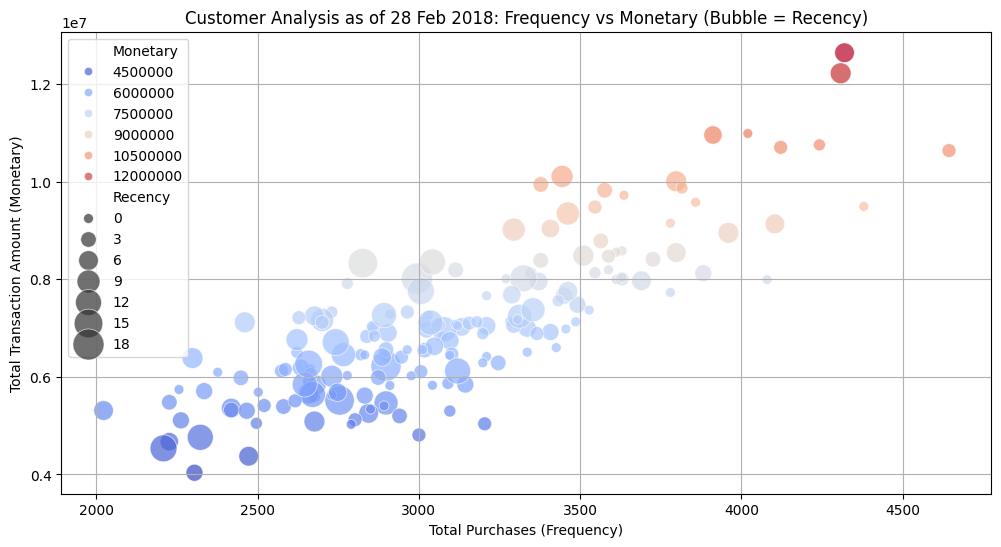

In [32]:
# Visualization: Frequency vs Monetary
# Filter out unreasonable values for visualization
customers_viz = customers[(customers['Recency'] >= 0) & (customers['Monetary'] > 0)]

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=customers_viz,
    x='Frequency',
    y='Monetary',
    size='Recency',
    hue='Monetary',
    palette='coolwarm',
    alpha=0.7,
    sizes=(50, 500)
)
plt.xlabel('Total Purchases (Frequency)')
plt.ylabel('Total Transaction Amount (Monetary)')
plt.title('Customer Analysis as of 28 Feb 2018: Frequency vs Monetary (Bubble = Recency)')
plt.grid(True)
plt.show()


In [33]:
# Calculate customer lifetime in days
customers['Customer_Lifetime_Days'] = (customers['last_purchase_date'] - customers['first_purchase_date']).dt.days

# Top 10 customers with the longest lifetime
top10_longest = customers.sort_values('Customer_Lifetime_Days', ascending=False).head(10)

# Top 10 customers with the shortest lifetime
top10_shortest = customers.sort_values('Customer_Lifetime_Days', ascending=True).head(10)

print("Top 10 Customers with Longest Lifetime")
print(top10_longest[['customer_name', 'Customer_Lifetime_Days']])

print("Top 10 Customers with Shortest Lifetime")
print(top10_shortest[['customer_name', 'Customer_Lifetime_Days']])



Top 10 Customers with Longest Lifetime
     customer_name  Customer_Lifetime_Days
12      Ella Lopez                    1519
21   Victoria Hall                    1519
155    Aiden White                    1519
124     Karen Wood                    1519
34   Stella Flores                    1518
43   Penelope Gray                    1518
32     Maya Torres                    1518
147   James Garcia                    1518
100  Carolyn Baker                    1518
135    Wendy Kelly                    1518
Top 10 Customers with Shortest Lifetime
         customer_name  Customer_Lifetime_Days
101      Debra Roberts                    1484
0           Emma Smith                    1493
109       Paula Walker                    1494
60       Claire Foster                    1495
96        Angela Allen                    1495
39     Samantha Carter                    1496
152    Mason Hernandez                    1496
90        Diane Butler                    1498
13   Scarlett Anderson   

Conclusion:

The analysis of customer lifetime shows that the top 10 customers with the longest lifetimes have been active for around 1,518–1,519 days, demonstrating strong long-term engagement and loyalty. The customers with the shortest lifetimes, however, have still been active for 1,484–1,500 days, meaning even the “newer” customers have been with the company for a significant period. This highlights that most customers have long-term relationships, and strategies can focus on maintaining loyalty while further engaging the slightly newer segment.

In [34]:
# How much each customer spends per purchase
print("Top 5 Customers by Avg Transaction Value")
top_avg = customers.sort_values('Avg_Transaction_Value', ascending=False).head(5)
print(top_avg[['customer_name','Frequency','Monetary','Avg_Transaction_Value']])


Top 5 Customers by Avg Transaction Value
         customer_name  Frequency    Monetary  Avg_Transaction_Value
13   Scarlett Anderson       2826   8329801.8            2947.559023
72       Kaitlyn Ortiz       3378   9942223.8            2943.227886
41       Violet Morris       3444  10107003.6            2934.670035
99         Janet Green       4320  12641251.8            2926.215694
170         Riley Rose       2460   7116927.6            2893.060000


Conclusion:

The top 5 customers by average transaction value spend approximately $2,893–$2,948 per purchase, indicating that each transaction they make is high in value. While some of these customers, like Janet Green and Violet Morris, also have high purchase frequencies and total spending, others such as Riley Rose have slightly lower frequency and total monetary contribution, showing that high-value transactions do not always correlate with the number of purchases. This highlights a valuable customer segment whose individual purchases contribute significantly to revenue, making them ideal targets for premium offers, upselling, or loyalty programs focused on maximizing transaction value.

These are all the key insights explored in this EDA, with a main focus on sales.